## On the use of hierarchical Bayesian modelling for stochastic crack growth monitoring

### Case 1 - Modelling stochastic crack growth using a modified Paris' law model: a general description

This notebook describes a framework for modelling stochastic crack growth using a modified version of Paris' law, which involves a time-discretisation during the crack propagation phase and the application of the conventional Paris' law for each time interval. This modified version of the Paris law model is inspired by structures subjected to operational conditions leading to time-varying fatigue loads, which lead to steady state conditions for considerable amounts of time. The objective behind this modelling choice is twofold: to predict crack growth more accurately and to provide a model that is amenable to hierarchical Bayesian modelling, which can be used to improve inference of time-invariant parameters (fixed effects) in the Paris' law model, which conventionally suffers from identifiability issues.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
import numpy as np

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader
from src.visualisation import plot_paris_predictions


First, we will load some stochastic crack growth data from another simulation to take advantage of the available simulation parameters which will lead to a physically meaningful demonstration. 

In [3]:
data_loader = SCGDataLoader()
data = data_loader.load_data()

In [4]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.linspace(10, 40, instances.shape[0])
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

Now, we can use this data to generate different crack growth instances using the conventional Paris law model.

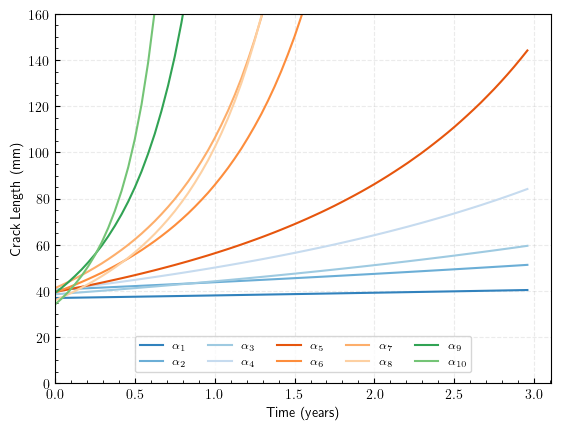

In [5]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(6.4, 4.8),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 8851:
logC: -29.2492
m: 2.9886
ds: 23.3333
navg: 2793155.5950
a0: 39.6060


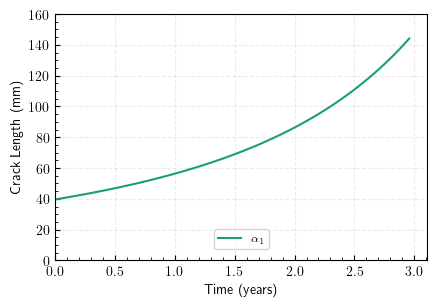

In [6]:
# Let's also test a single prediction to understand what's going on
inst = instances[4]
c = paris_params[0][4]
m = paris_params[1][4]
ds = stress_ranges[4]
navg = n_cycles[4]
a0 = initial_crack_lengths[4]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {np.log(c):.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions(
    paris_params=(c, m),
    ds=ds,
    navg=navg,
    a0=a0,
    times=time_array,
    figsize=(4.8, 3.2),
    cmap_name='Dark2'
)

We can also take a look at the sensitivity of Paris law with respect to the three main parameters that represent quantities of interest for us, namely the Paris law parameters $C, m$ and the stress range $\Delta S$.

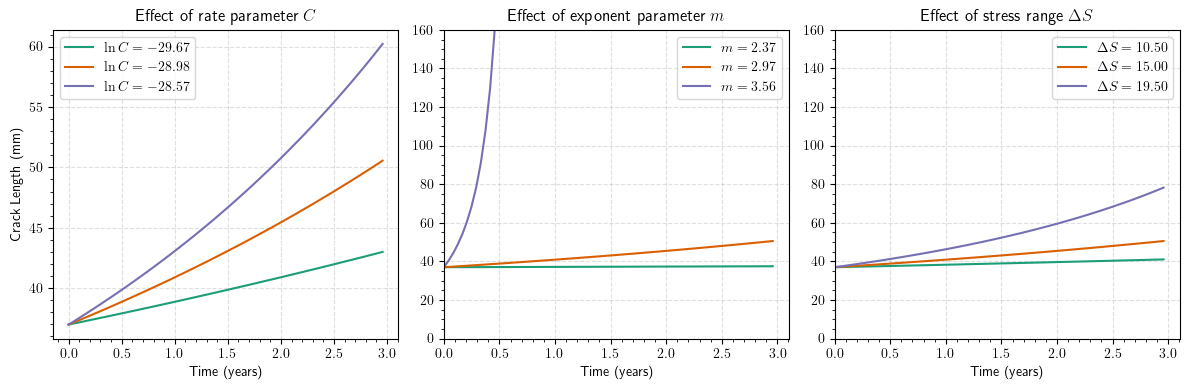

In [7]:
# Let's also explore how different parameters affect crack growth
from src.visualisation import plot_parameter_sensitivity

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = 15.0
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Use the new modular function for parameter sensitivity analysis
fig, axes = plot_parameter_sensitivity(
    base_c=base_c,
    base_m=base_m,
    base_ds=base_ds,
    base_navg=base_navg,
    base_a0=base_a0,
    times=time_array,
    save_fig_name="parameter_sensitivity.pdf",
)

# You can still customize the plot if needed
# axes[1].set_ylim(bottom=0, top=160)

## Testing Variable Stress Paris-Erdogan Model

This section demonstrates how to use the `VariableStressParisErdogan` model for simulating crack growth with time-varying stress ranges.

Average stress: 17.00 MPa
Stress range: 5.0 - 30.0 MPa


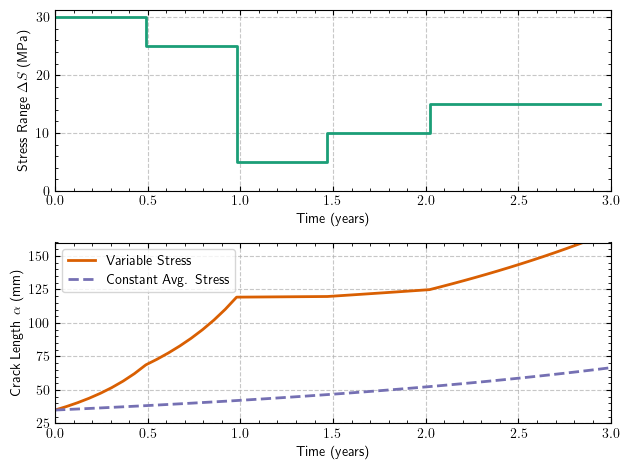

In [8]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 5.0),
    (1.5, 2.0, 10.0),
    (2.0, 3.0, 15.0),
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(1e-13),
    m=3.2,
    navg=3e6,
    a0=35.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name="variable_stress_comparison.pdf"
)

# Print some interesting statistics about the plot
print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

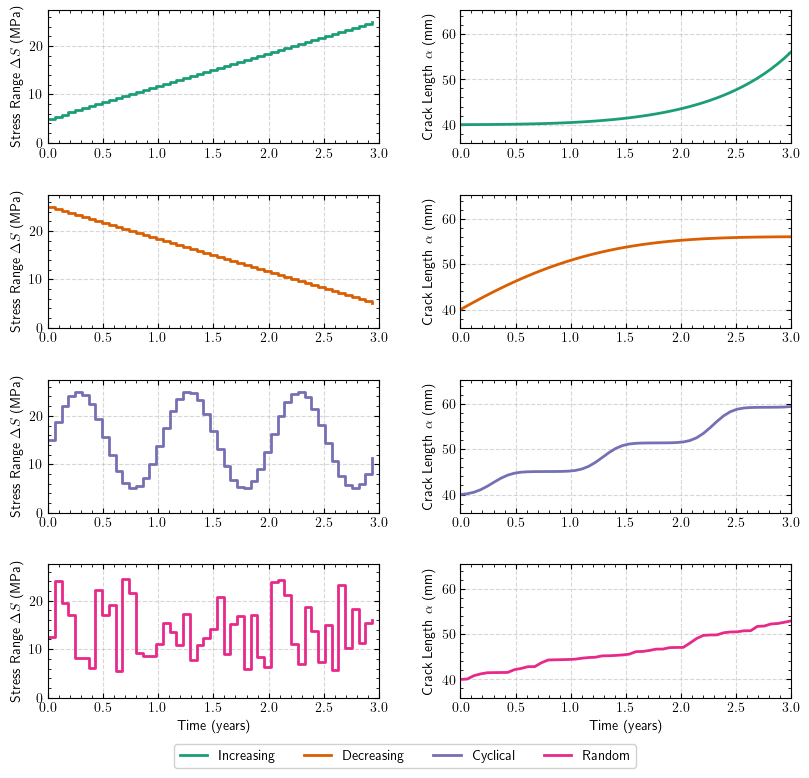

In [9]:
from src.visualisation import plot_stress_pattern_comparison

# Set parameters
logc = np.log(5e-14)  # Natural log of Paris law C parameter
m = 3.2               # Paris law exponent m
navg = 2.8e6          # Average cycles per year
a0 = 40.0             # Initial crack length (mm)

# Use the new function to create the comparison plot
fig, axes = plot_stress_pattern_comparison(
    logc=logc,
    m=m,
    navg=navg,
    a0=a0,
    min_stress=5.0,
    max_stress=25.0,
    patterns=['increasing', 'decreasing', 'cyclical', 'random'],
    cmap_name='Dark2',
    figsize=(8.2, 8.2),
    save_fig_name="stress_pattern_comparison.pdf"
)

# Print analysis of the results
# print("Final crack lengths with varying stress patterns:")
# for pattern, length in stats['final_lengths'].items():
#     print(f"{pattern.capitalize():<12}: {length:.2f} mm")

# print("\nAverage stress for each pattern:")
# for pattern, avg_stress in stats['avg_stresses'].items():
#     print(f"{pattern.capitalize():<12}: {avg_stress:.2f} MPa")

# print("\nEffect of stress pattern (Length/Stress ratio):")
# for pattern, ratio in stats['length_stress_ratio'].items():
#     print(f"{pattern.capitalize():<12}: {ratio:.2f}")

# # Explanation of why patterns with same average stress produce different results
# print("\nObservation: Even with the same average stress, patterns produce")
# print(r"different final crack lengths because of the power law $(da/dN ∝ \Delta K^m)$.")
# print(f"When $m > 1$ (here m = {m:.1f}), high stress periods contribute")
# print("disproportionately more to crack growth than low stress periods.")


## Demonstrating Single Task Learning with Multiple Components

In this section, we'll create three different components (tasks) with the same Paris law parameters but different initial crack lengths and stress ranges. This controlled scenario will allow us to later compare single-task vs. multi-task learning approaches.

In [10]:
import matplotlib.pyplot as plt

# Define common Paris law parameters for all components
common_logc = np.log(np.exp(-29.8)) # Natural logarithm of Paris C parameter
common_m = 3.12               # Paris law exponent
common_navg = 2.8e6          # Average cycles per year

# Define different initial crack lengths for the three components
initial_crack_lengths = np.array([41.0, 37.0, 39.0])

# Define different stress ranges for the three components
stress_ranges = np.array([16.0, 22., 19.0])

# Create a time array for predictions
time_array = np.linspace(0, 3.0, 72)

# Print the parameters for reference
print("Common parameters for all components:")
print(f"logC = {common_logc:.4f}")
print(f"m = {common_m:.4f}")
print(f"navg = {common_navg:.1f} cycles/year")
print("\nComponent-specific parameters:")
for i in range(3):
    print(f"Component {i+1}: Initial crack length = {initial_crack_lengths[i]:.2f} mm, Stress range = {stress_ranges[i]:.2f} MPa")

Common parameters for all components:
logC = -29.8000
m = 3.1200
navg = 2800000.0 cycles/year

Component-specific parameters:
Component 1: Initial crack length = 41.00 mm, Stress range = 16.00 MPa
Component 2: Initial crack length = 37.00 mm, Stress range = 22.00 MPa
Component 3: Initial crack length = 39.00 mm, Stress range = 19.00 MPa


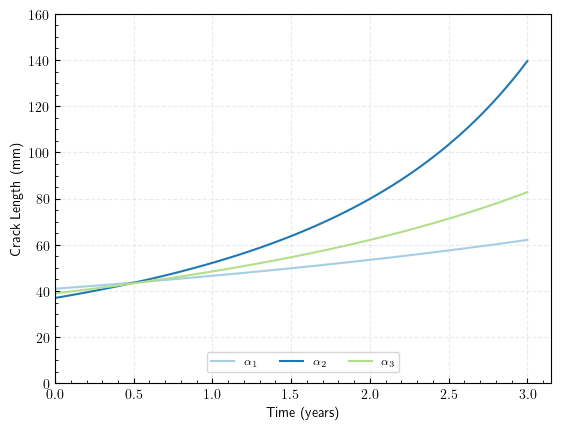

In [11]:
# Use plot_paris_predictions to visualize the crack growth for our components
from src.visualisation import plot_paris_predictions

# Convert logC to C for the paris_params format
common_c = np.exp(common_logc)
paris_params = (np.array([common_c, common_c, common_c]), 
               np.array([common_m, common_m, common_m]))

fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=np.array([common_navg, common_navg, common_navg]),
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="controlled_components_growth.pdf",
    figsize=(6.4, 4.8),
    plot_grid=True,
    cmap_name='Paired'
)

The plot above shows crack growth trajectories for three components that share the same Paris law parameters but have different initial conditions (crack length) and loading conditions (stress range). 

Component 2 shows the fastest growth rate due to its higher stress range, whilst Component 1 has the slowest growth. This controlled scenario is ideal for our hierarchical Bayesian modelling approach, as we have a known "ground truth" for the shared parameters.

In the next section, we'll generate simulated observations from these trajectories and perform Bayesian inference.

In [12]:
# Generate the full crack growth data for reference
from src.predictive_models import CrackGrowthPredictor

# Create predictor
predictor = CrackGrowthPredictor()

# Generate full crack growth trajectories
crack_lengths = np.zeros((3, len(time_array)))

for i in range(3):
    crack_lengths[i] = predictor.predict_crack_growth(
        logc=common_logc,
        m=common_m,
        ds=stress_ranges[i],
        navg=common_navg,
        a0=initial_crack_lengths[i],
        times=time_array
    )

# Save these trajectories for later use in Bayesian inference
controlled_data = {
    'times': time_array,
    'crack_lengths': crack_lengths,
    'paris_c': np.array([common_c, common_c, common_c]),
    'paris_m': np.array([common_m, common_m, common_m]),
    'initial_crack_length': initial_crack_lengths,
    'stress_ranges': stress_ranges,
    'navg': np.array([common_navg, common_navg, common_navg])
}

print(f"Generated crack length arrays with shape: {crack_lengths.shape}")
print(f"Final crack lengths after {time_array[-1]:.1f} years:")
for i in range(3):
    print(f"Component {i+1}: {crack_lengths[i, -1]:.2f} mm")

Generated crack length arrays with shape: (3, 72)
Final crack lengths after 3.0 years:
Component 1: 62.15 mm
Component 2: 139.59 mm
Component 3: 82.83 mm


Now, we can convert the `controlled_data` dictionary to a format that is consistent with what is expected by the `CrackObservationGenerator` class.

In [13]:
trajectories = {
    'times': [time_array for _ in range(3)],  # Same time array for all components
    'crack_lengths': [crack_lengths[i] for i in range(3)],
    'paris_c': controlled_data['paris_c'],
    'paris_m': controlled_data['paris_m'],
    'initial_crack_length': controlled_data['initial_crack_length']
}

We can now create an instance of the observation generator and generate some synthetic data which we'll use for inference. We will employ a uniform sampling over the monitoring lifetime and add some zero-mean Gaussian noise with a standard deviation of 1.5 mm.

In [14]:
from src.data_utils import CrackObservationGenerator

# Create observation generator with the formatted trajectories
obs_generator = CrackObservationGenerator(trajectories, random_seed=42)

# Generate uniform observations with moderate noise
uniform_observations = obs_generator.create_observations(
    n_points=8,            # 8 observations per component
    strategy='uniform',    # Evenly spaced observations
    std_dev=1.5,           # 1.5mm standard deviation noise
    include_endpoints=True,
    random_seed=42
)

Let's plot our observations alongside the target crack growth trajectories to make sure everything is as expected.

In [15]:
from src.visualisation import plot_trajectories_with_observations

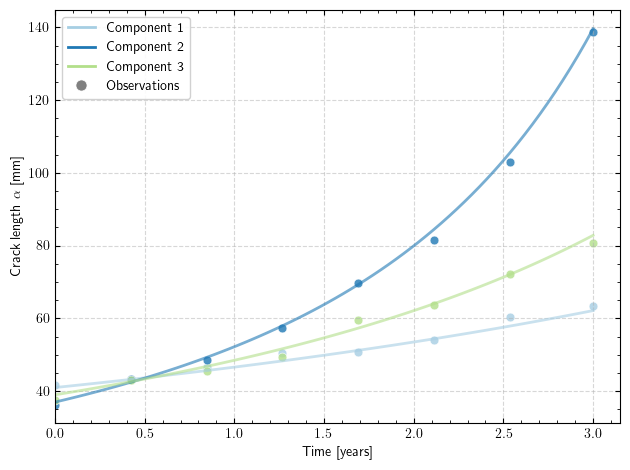

In [16]:
fig, ax = plot_trajectories_with_observations(
    times=trajectories['times'],
    crack_lengths=trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(3)],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=0.8,
    marker_size=40,
    save_fig_name="classic_paris_observations_stl.pdf"
)


## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [17]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace, plot_prior_posterior_comparison, plot_posterior_predictive_stl

# Set a seed for reproducibility
np.random.seed(42)

In [18]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.Normal(3.2, 0.5),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

In [ ]:
# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(trajectories['paris_c'][component_idx])
true_m = trajectories['paris_m'][component_idx]
true_a0 = trajectories['initial_crack_length'][component_idx]
true_ds = controlled_data['stress_ranges'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")
print(f"ds: {true_ds:.4f} MPa")

True parameters for component 3:
logC: -29.8000
m: 3.1200
a0: 39.0000
ds: 19.0000 MPa


In [94]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 4000/4000 [00:01<00:00, 2651.66it/s, 671 steps of size 5.31e-03. acc. prob=0.95] 

sample: 100%|██████████| 4000/4000 [00:01<00:00, 2850.80it/s, 87 steps of size 5.99e-03. acc. prob=0.91]  



In [95]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                              mean     sd  hdi_3%  hdi_97%  mcse_mean  \
ds                          18.866  8.002   5.328   33.866      0.131   
logc                       -28.707  1.627 -31.828  -25.864      0.028   
m                            3.015  0.298   2.423    3.540      0.005   
noise_std                    1.695  0.501   0.847    2.572      0.009   
predicted_crack_lengths[0]  41.238  0.164  40.941   41.551      0.003   
predicted_crack_lengths[1]  45.574  0.324  44.963   46.170      0.005   
predicted_crack_lengths[2]  50.612  0.472  49.728   51.486      0.008   
predicted_crack_lengths[3]  56.511  0.602  55.393   57.646      0.009   
predicted_crack_lengths[4]  63.477  0.724  62.118   64.814      0.009   
predicted_crack_lengths[5]  71.783  0.909  70.147   73.577      0.010   
predicted_crack_lengths[6]  81.799  1.350  79.387   84.497      0.016   

                            mcse_sd  ess_bulk  ess_tail  r_hat  
ds                            0.108  3447.978  2662.402  1

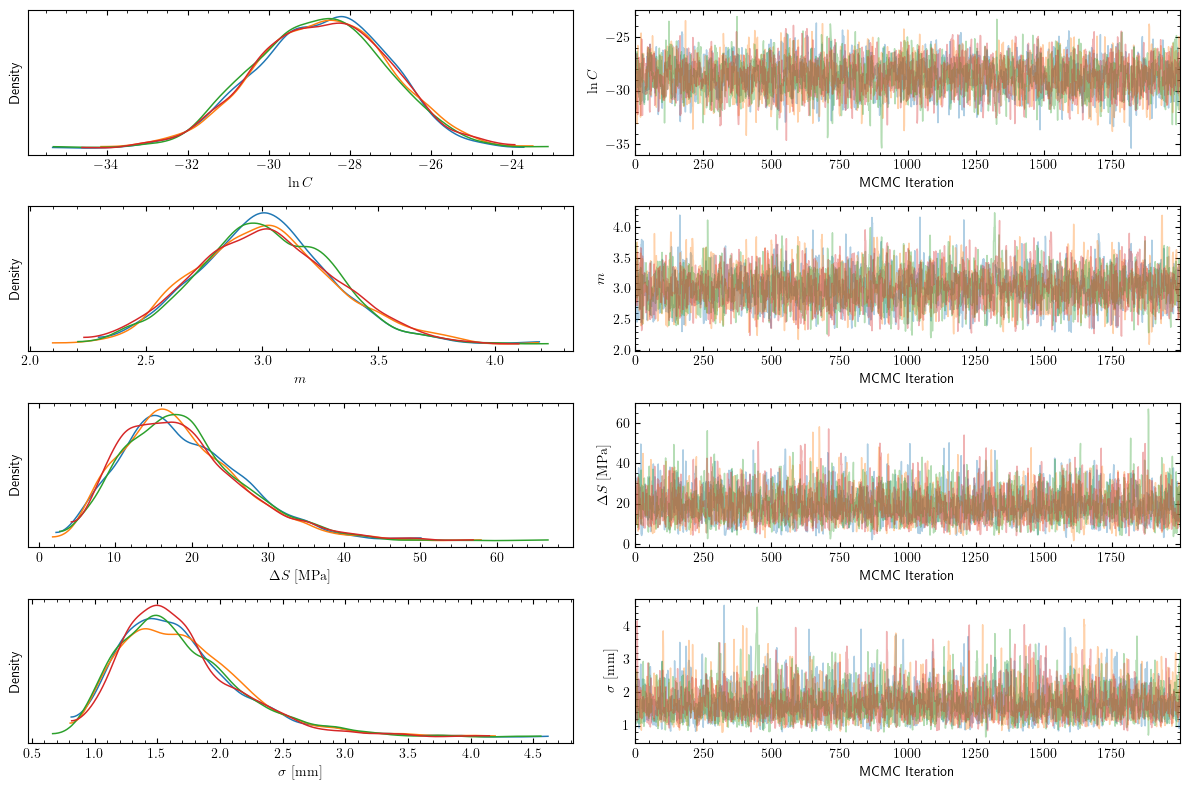

In [96]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="posterior_traces_classic_stl_c3.pdf")

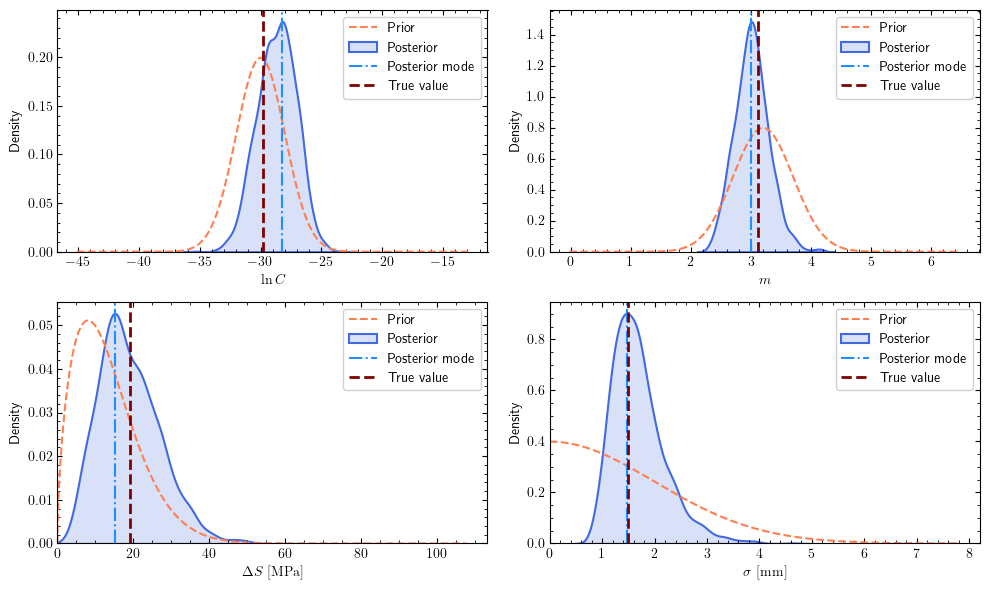

In [97]:
# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "ds": true_ds,
    "noise_std": 1.5  # Noise used in generating observations
}

# Extract posterior samples
posterior_samples = results['samples']

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(10.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_posterior_comparison_classic_stl_c3.pdf",
    use_first_chain_only=True,
    prior_range_extension=2.5
)

In [ ]:
# Generate predictions using the preferred posterior predictive sampling method
# Note: The legacy generate_predictions method is deprecated
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [99]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = trajectories['times'][component_idx]
true_crack_lengths = trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]



Comparison of statistics:
Predictions RMSE: 1.372 mm
Observations RMSE: 1.374 mm

95% CI width at final time:
Predictions: 5.55 mm
Observations: 8.86 mm


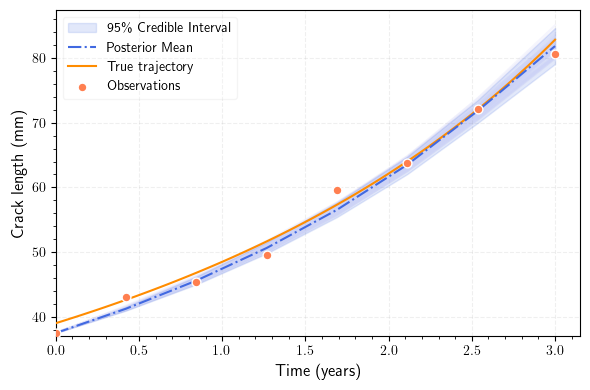

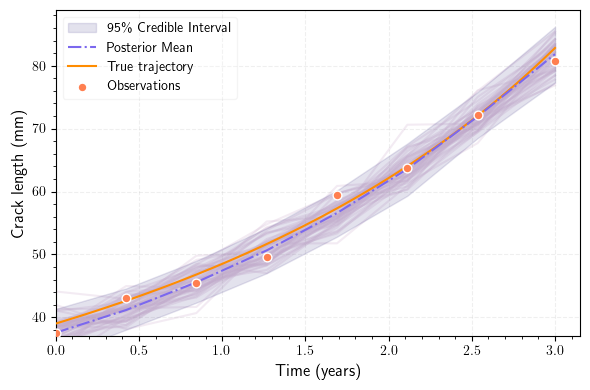

In [101]:
# Generate predictions using the proper posterior predictive sampling method
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

# Plot the predicted crack lengths (default behavior)
fig1, ax1, stats1 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    save_fig_name="posterior_predictive_predictions_classic_stl_c3.pdf"
)

# Plot only the observations with noise
fig2, ax2, stats2 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    plot_type="observations",  # Plot observations instead of predictions
    save_fig_name="posterior_predictive_observations_classic_stl_c3.pdf"
)

# Print comparison of statistics
print("\nComparison of statistics:")
print(f"Predictions RMSE: {stats1['rmse']:.3f} mm")
print(f"Observations RMSE: {stats2['rmse']:.3f} mm")

print("\n95% CI width at final time:")
print(f"Predictions: {stats1['ci_width'][-1]:.2f} mm")
print(f"Observations: {stats2['ci_width'][-1]:.2f} mm")


## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="numpyro.infer.mcmc")

In [19]:
from src.output_utils import calculate_component_metrics, format_comparison_table, save_results_table

# Now let's run the model on all three components to compare performance
component_results = []

for i in range(3):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(trajectories['paris_c'][i])
    true_m = trajectories['paris_m'][i]
    true_a0 = trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=500,
        num_samples=1000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'ds': controlled_data['stress_ranges'][i],
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['summary']['mean']['logc'],
            'logc_sd': results['summary']['sd']['logc'],
            'm': results['summary']['mean']['m'],
            'm_sd': results['summary']['sd']['m'],
            'ds': results['summary']['mean']['ds'],
            'ds_sd': results['summary']['sd']['ds'],
            'noise_std': results['summary']['mean']['noise_std'],
            'noise_std_sd': results['summary']['sd']['noise_std']
        }
    })



Running inference for component 1...
True parameters for component 1:
logC: -29.8000
m: 3.1200
a0: 41.0000


/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 1500/1500 [00:00<00:00, 3346.74it/s, 263 steps of size 8.07e-03. acc. prob=0.94]

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the begin


Running inference for component 2...
True parameters for component 2:
logC: -29.8000
m: 3.1200
a0: 37.0000


sample: 100%|██████████| 1500/1500 [00:01<00:00, 955.16it/s, 1023 steps of size 2.34e-03. acc. prob=0.94] 

sample: 100%|██████████| 1500/1500 [00:00<00:00, 1682.44it/s, 1023 steps of size 1.47e-03. acc. prob=0.96]
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn 


Running inference for component 3...
True parameters for component 3:
logC: -29.8000
m: 3.1200
a0: 39.0000


sample: 100%|██████████| 1500/1500 [00:00<00:00, 2454.36it/s, 1023 steps of size 5.46e-03. acc. prob=0.95]



In [20]:
# Use our new output_utils module to create the comparison table
comparison_df = calculate_component_metrics(component_results)

# Format the table with 4 decimal places
formatted_df = format_comparison_table(comparison_df, precision=4)

In [21]:
formatted_df

,Component,logc (True),logc (Inferred),logc (Std),logc (Error),logc (% Error),ds (True),ds (Inferred),ds (Std),ds (Error),...,m (True),m (Inferred),m (Std),m (Error),m (% Error),noise_std (True),noise_std (Inferred),noise_std (Std),noise_std (Error),noise_std (% Error)
0,1,-29.8,-29.847,1.658,0.047,0.157718,16.0000,14.2140,7.0900,+1.7860,...,3.1200,3.3050,0.3470,-0.1850,-5.9295%,1.5,1.285,0.409,0.215,14.333333
1,2,-29.8,-29.826,1.590,0.026,0.087248,22.0000,14.1200,6.1290,+7.8800,...,3.1200,3.4760,0.1520,-0.3560,-11.4103%,1.5,1.771,0.541,-0.271,-18.066667
2,3,-29.8,-28.629,1.606,-1.171,-3.929530,19.0000,18.3770,8.0650,+0.6230,...,3.1200,3.0180,0.2930,+0.1020,+3.2692%,1.5,1.690,0.521,-0.190,-12.666667


## Multi-Task Learning (MTL) with Hierarchical Bayesian Modelling

So far, we have applied **Single-Task Learning (STL)** where each component is modelled independently. Whilst this approach works, it doesn't take advantage of the fact that our three components share the same underlying Paris law parameters (`logC = -29.8`, `m = 3.12`).

### The Problem with Independent Modelling

When we model each component separately:
- Each component's inference is based only on its own limited observations
- We don't share information between components that might have similar physics
- This can lead to higher uncertainty and potentially biased estimates, especially with limited data

### The Multi-Task Learning Solution

**Multi-Task Learning (MTL)** treats the inference problem as learning multiple related tasks simultaneously. In our crack growth context:

- **Tasks**: Each component represents a different "task"
- **Shared Parameters**: Paris law parameters (C, m) and observation noise that are common across all components
- **Component-Specific Parameters**: Stress ranges that vary by component and must be inferred

### Hierarchical Bayesian Framework

We implement MTL using a **hierarchical Bayesian model** with two levels:

1. **Fixed Effects (Population Level)**:
   - Paris law parameters `logC` and `m` are shared across all components (material properties)
   - Observation noise `σ` is shared across all components (measurement system properties)

2. **Random Effects (Component Level)**:
   - Stress ranges `Δσᵢ` vary by component and are inferred from the crack growth data
   - These represent unknown or uncertain loading conditions for each component

3. **Known Constants (Task-Specific)**:
   - Initial crack lengths `a₀ᵢ` are measured at baseline for each component

### Why This Structure Makes Sense

This hierarchical structure reflects realistic engineering scenarios:

- **Material properties** (`logC`, `m`) should be consistent across components made of the same material
- **Measurement precision** (`σ`) should be consistent when using the same monitoring equipment
- **Initial crack sizes** (`a₀ᵢ`) can be measured directly at the start of monitoring
- **Stress conditions** (`Δσᵢ`) are often unknown or highly uncertain in practice, making their inference from crack growth data extremely valuable

### Expected Benefits

By pooling information across components, MTL should:
- **Reduce uncertainty** in estimates of shared material properties
- **Improve accuracy** especially when individual components have limited data
- **Enable stress inference** from crack growth observations, providing valuable insights into actual loading conditions
- **Provide better predictions** by leveraging the full dataset
- **Enable knowledge transfer** from data-rich to data-poor components

Let's implement this approach and compare it with our STL results!

### Implementing the MTL Bayesian Model

Now let's implement the hierarchical Bayesian model that jointly learns from all components simultaneously. This model will treat the Paris law parameters (`logC`, `m`) and observation noise (`σ`) as **population-level (fixed effects)** parameters shared across all components, while inferring component-specific **stress ranges** (`Δσᵢ`) as **random effects**.

In [60]:
# Define priors for Multi-Task Learning (MTL) with conditional hyperpriors
import numpyro.distributions as dist

# MTL priors for shared parameters (fixed effects)
mtl_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = {
    "weibull_concentration": dist.Gamma(10.0, 1.0),  # Shape parameter for ds distribution
    "weibull_scale": dist.Gamma(15.0, 1.0)           # Scale parameter for ds distribution
}

# print("MTL Priors (shared parameters):")
# for name, prior in mtl_priors.items():
#     print(f"  {name}: {prior}")

# print("\nHyperpriors (stress range distribution):")
# for name, hyperprior in hyperpriors.items():
#     print(f"  {name}: {hyperprior}")

# print("\nModel behavior:")
# print("- With hyperpriors: Hierarchical MTL (stress ranges learn population distribution)")
# print("- Without hyperpriors: Simple MTL (stress ranges are i.i.d.)")

In [61]:
# Create MTL Bayesian model with conditional hyperpriors
from src.bayesian_models import MTLBayesianModel

# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
mtl_model = MTLBayesianModel(
    priors=mtl_priors,                    # Fixed effects priors
    crack_growth_data=uniform_observations, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

print("MTL Model Configuration:")
print(f"- Number of components: {len(uniform_observations['times'])}")
print(f"- Shared parameters: {list(mtl_priors.keys())}")
print(f"- Component-specific parameters: stress ranges (ds)")
print(f"- Hyperprior mode: {'Hierarchical' if hyperpriors else 'Simple'}")
print(f"- Observations per component: {[len(times) for times in uniform_observations['times']]}")

MTL Model Configuration:
- Number of components: 3
- Shared parameters: ['logc', 'm', 'noise_std']
- Component-specific parameters: stress ranges (ds)
- Hyperprior mode: Hierarchical
- Observations per component: [8, 8, 8]


In [62]:
# Run hierarchical MTL inference
print("Running hierarchical Multi-Task Learning inference...")
print("This jointly learns from all components while sharing information about:")
print("- Material properties (logC, m)")
print("- Measurement system (noise_std)")
print("- Stress range population distribution (via hyperpriors)")

mtl_results = mtl_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)

print("\nInference completed!")
print(f"Inferred shared parameters:")
print(f"  logC: {mtl_results['summary']['mean']['logc']:.4f} ± {mtl_results['summary']['sd']['logc']:.4f} (true: {true_logc:.4f})")
print(f"  m: {mtl_results['summary']['mean']['m']:.4f} ± {mtl_results['summary']['sd']['m']:.4f} (true: {true_m:.4f})")
print(f"  noise_std: {mtl_results['summary']['mean']['noise_std']:.4f} ± {mtl_results['summary']['sd']['noise_std']:.4f} (true: 1.5 mm)")

print(f"\nLearned population distribution parameters:")
print(f"  Weibull concentration: {mtl_results['summary']['mean']['weibull_concentration']:.3f} ± {mtl_results['summary']['sd']['weibull_concentration']:.3f}")
print(f"  Weibull scale: {mtl_results['summary']['mean']['weibull_scale']:.3f} ± {mtl_results['summary']['sd']['weibull_scale']:.3f}")

print(f"\nInferred component stress ranges:")
for i in range(3):
    mean_ds = mtl_results['summary']['mean'][f'ds[{i}]']
    sd_ds = mtl_results['summary']['sd'][f'ds[{i}]']
    true_ds = controlled_data['stress_ranges'][i]
    print(f"  Component {i+1}: {mean_ds:.2f} ± {sd_ds:.2f} MPa (true: {true_ds:.1f} MPa)")

Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (via hyperpriors)


Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (via hyperpriors)


sample: 100%|██████████| 4000/4000 [00:05<00:00, 760.65it/s, 1023 steps of size 2.54e-03. acc. prob=0.96] 

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1078.22it/s, 1023 steps of size 3.48e-03. acc. prob=0.91]

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1036.27it/s, 47 steps of size 3.03e-03. acc. prob=0.94]  

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1039.73it/s, 63 steps of size 2.90e-03. acc. prob=0.94]  



Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (via hyperpriors)


sample: 100%|██████████| 4000/4000 [00:05<00:00, 760.65it/s, 1023 steps of size 2.54e-03. acc. prob=0.96] 

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1078.22it/s, 1023 steps of size 3.48e-03. acc. prob=0.91]

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1036.27it/s, 47 steps of size 3.03e-03. acc. prob=0.94]  

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1039.73it/s, 63 steps of size 2.90e-03. acc. prob=0.94]  




Inference completed!
Inferred shared parameters:
  logC: -29.1090 ± 1.1000 (true: -29.8000)
  m: 3.4470 ± 0.1370 (true: 3.1200)
  noise_std: 1.5740 ± 0.2610 (true: 1.5 mm)

Learned population distribution parameters:
  Weibull concentration: 10.627 ± 2.917
  Weibull scale: 12.424 ± 2.866

Inferred component stress ranges:
  Component 1: 8.25 ± 2.27 MPa (true: 16.0 MPa)
  Component 2: 11.31 ± 3.13 MPa (true: 22.0 MPa)
  Component 3: 9.94 ± 2.74 MPa (true: 19.0 MPa)


In [63]:
# Print full posterior summary
mtl_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")

                                  mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds[0]                            8.253  2.271    4.131   12.322      0.069   
ds[1]                           11.307  3.132    5.574   16.917      0.095   
ds[2]                            9.939  2.742    4.921   14.860      0.084   
logc                           -29.109  1.100  -31.232  -27.126      0.032   
m                                3.447  0.137    3.185    3.712      0.002   
noise_std                        1.574  0.261    1.119    2.066      0.005   
predicted_crack_lengths[0, 0]   43.999  0.086   43.840   44.164      0.001   
predicted_crack_lengths[0, 1]   46.468  0.187   46.114   46.816      0.002   
predicted_crack_lengths[0, 2]   49.179  0.306   48.588   49.741      0.004   
predicted_crack_lengths[0, 3]   52.170  0.447   51.285   52.968      0.005   
predicted_crack_lengths[0, 4]   55.482  0.616   54.284   56.600      0.007   
predicted_crack_lengths[0, 5]   59.166  0.822   57.546   60.625 

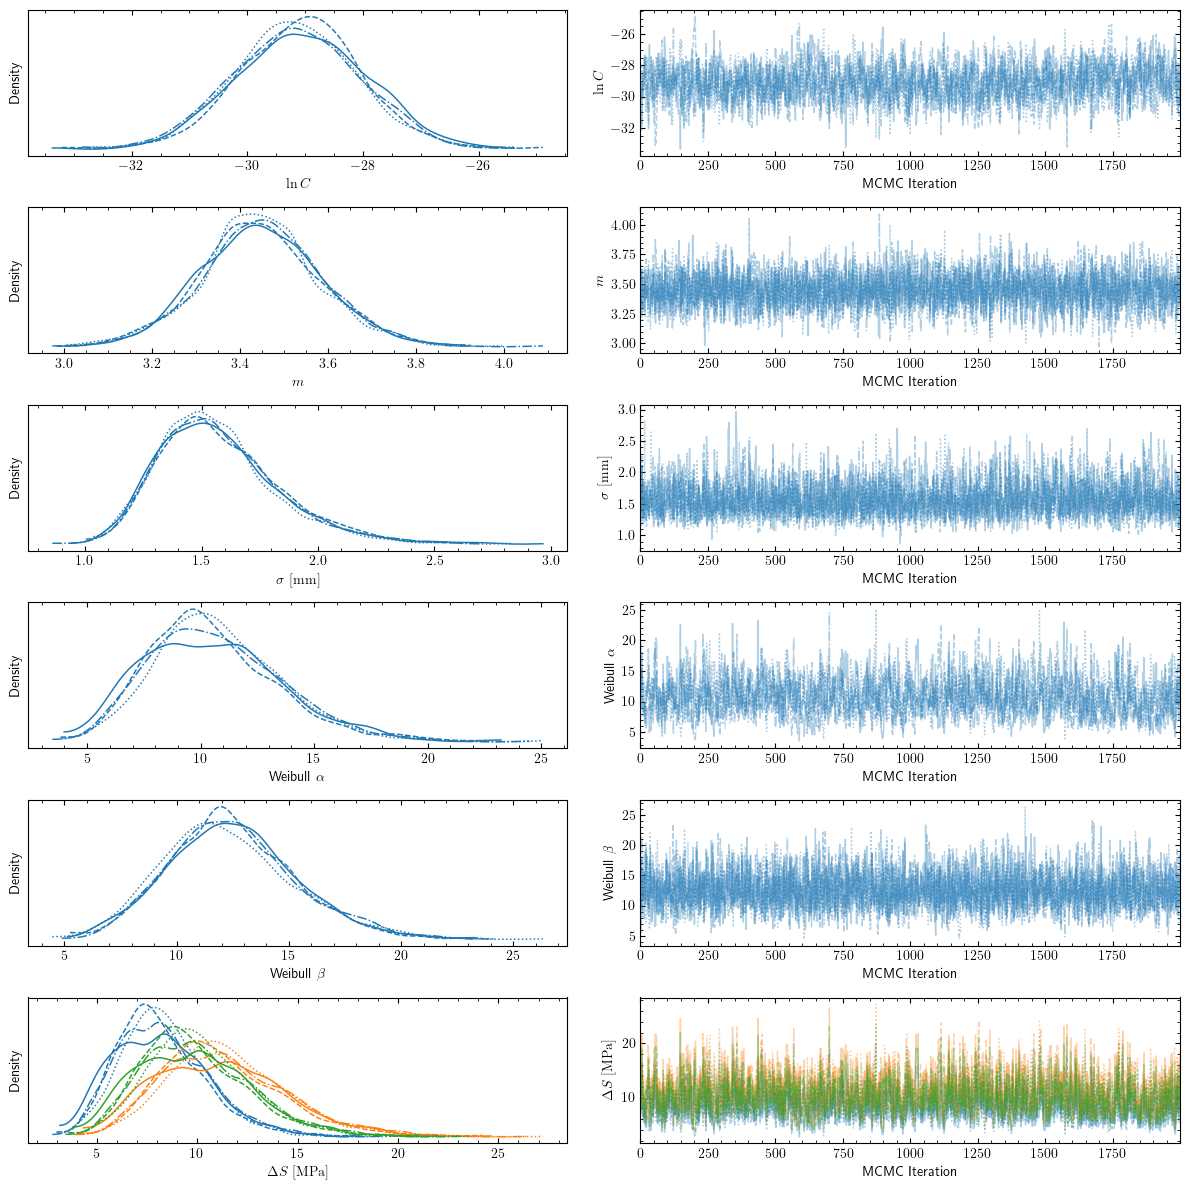

In [64]:
# Visualize MTL posterior traces to check convergence
from src.visualisation import plot_posterior_trace

# Define variables to plot - include shared parameters and hyperpriors
mtl_var_names = ["logc", "m", "noise_std", "weibull_concentration", "weibull_scale", "ds"]
mtl_plot_labels = [
    r"$\ln C$", 
    r"$m$", 
    r"$\sigma \ \mathrm{[mm]}$",
    r"Weibull $\alpha$",
    r"Weibull $\beta$",
    r"$\Delta S \ \mathrm{[MPa]}$"
]

# Create trace plots for MTL parameters
plot_posterior_trace(
    mtl_results['samples'], 
    var_names=mtl_var_names, 
    plot_var_names=mtl_plot_labels,
    compact=True)

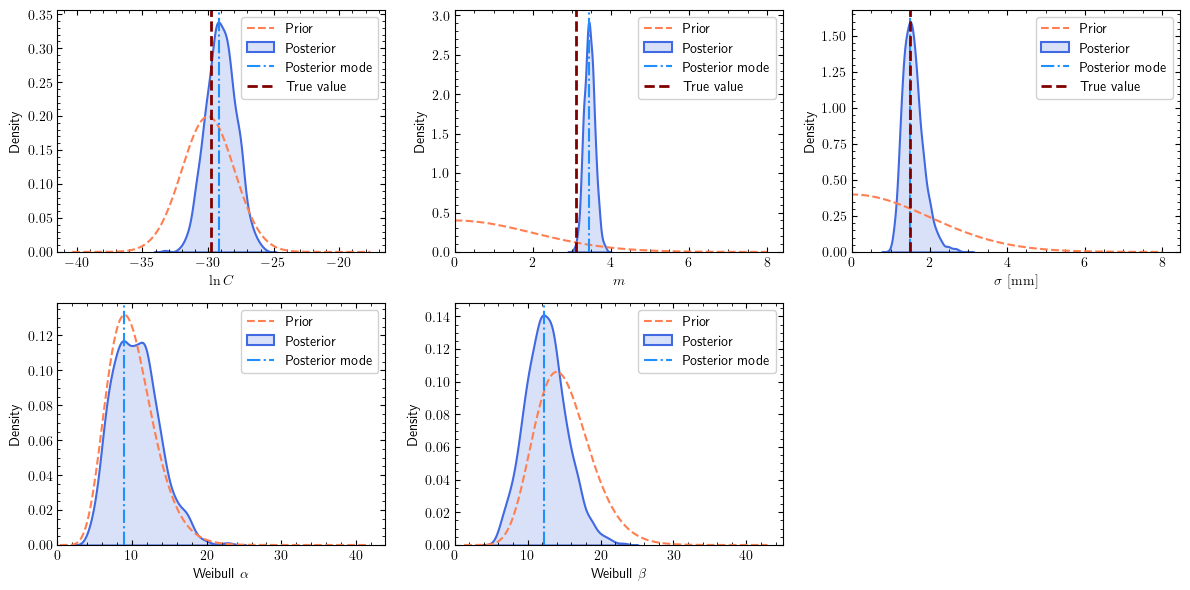

In [74]:
# Compare MTL priors vs posteriors with true values for ALL parameters
from src.visualisation import plot_prior_posterior_comparison

# First, let's create extended priors that include all parameters in the MTL model
# We need to add component-specific priors for stress ranges
mtl_extended_priors = mtl_priors.copy()  # Start with population-level priors
# Also add the hyperpriors to the extended priors dictionary
mtl_extended_priors.update(hyperpriors)

# Define true values for ALL MTL parameters
mtl_extended_true_values = {
    # Population-level parameters (shared across components)
    "logc": true_logc,  # True shared logC
    "m": true_m,        # True shared m  
    "noise_std": 1.5,   # True observation noise
    
    # Component-specific stress ranges (true values)
    "ds[0]": controlled_data['stress_ranges'][0],  # Component 1: 16.0 MPa
    "ds[1]": controlled_data['stress_ranges'][1],  # Component 2: 22.0 MPa
    "ds[2]": controlled_data['stress_ranges'][2],  # Component 3: 19.0 MPa
    
    # Hyperpriors don't have "true" values since they're learned from data
    # We'll omit them from true_values so they don't get vertical lines
}

# Create comprehensive variable list for all MTL parameters
all_mtl_vars = [
    # Population-level (shared) parameters
    "logc", "m", "noise_std",
    # Hyperprior parameters  
    "weibull_concentration", "weibull_scale",
]

# Create display labels for all parameters
all_mtl_labels = {
    # Population-level parameters
    "logc": r"$\ln C$",
    "m": r"$m$", 
    "noise_std": r"$\sigma \ \mathrm{[mm]}$",
    
    # Hyperprior parameters
    "weibull_concentration": r"Weibull $\alpha$",
    "weibull_scale": r"Weibull $\beta$",
}

# Create the comprehensive comparison plot
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=mtl_results['samples'],
    prior_dists=mtl_extended_priors,
    true_values=mtl_extended_true_values,
    var_names=all_mtl_vars,
    plot_var_names=all_mtl_labels,
    figsize=(12.0, 6.0),  # Larger figure to accommodate all parameters
    n_cols=3,              # 3 columns for better layout
    point_estimate='mode',
    save_fig_name="comprehensive_mtl_prior_posterior_comparison.pdf",
    use_first_chain_only=True,
    prior_range_extension=1.5
)